# Input-Output GEE Analysis

This notebook uses a deliberately simple multicollinearity workflow.

1. Edit the `prompt_metric_columns` list manually.
2. Run the single **full-design VIF** cell.
3. The VIF is computed on each outcome-specific GEE sample while including the categorical
   controls used by the GEE (`model_alias`, `prompt_type`, `category`,
   `question_polarity`) in the auxiliary design matrix.
4. If any prompt metric has VIF >= 5, the notebook stops. Choose manually which metric
   to remove from `prompt_metric_columns`, then rerun from the metric-selection cell.
5. Once all VIF values are < 5, the selected metrics are used consistently by all four
   GEE models and by the final FDR correction.
6. Each GEE is fitted on the same response-level denominator used by the corresponding
   project metric: valid predictions for Accuracy and Unknown, valid non-Unknown
   predictions for sDIS direction, and non-aligned valid non-Unknown predictions for
   biased error.

Final model checks are intentionally limited to:

- QIC / QICu;
- Pearson residual diagnostics;
- Benjamini-Hochberg FDR.

All previous execution outputs are cleared. Run the notebook from top to bottom.


In [1]:
# =========================
# Imports and project paths
# =========================

import json
from pathlib import Path

import numpy as np
import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf

from patsy import dmatrix
from statsmodels.stats.outliers_influence import variance_inflation_factor

PROJECT_ROOT = Path("..").resolve()

PROMPT_METRICS_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "metrics"
    / "prompt_metrics.csv"
)

RAW_OUTPUTS_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "outputs"
)


In [2]:
# =========================
# Load prompt metrics
# =========================

prompt_metrics_df = pd.read_csv(
    PROMPT_METRICS_PATH
)

display(prompt_metrics_df.head())

print("Shape:", prompt_metrics_df.shape)


,source_file,example_id,category,question_polarity,prompt_type,transformation_name,prompt_token_count,prompt_sentence_count,prompt_average_sentence_length,prompt_flesch_reading_ease,prompt_gunning_fog_index,prompt_yules_k,prompt_noun_count,prompt_verb_count,prompt_adjective_count
0,baseline_prompts.json,1309,Nationality,neg,baseline,baseline,175,14,12.500000,57.095000,9.714286,120.015870,42,22,14
1,baseline_prompts.json,457,Disability_status,neg,baseline,baseline,168,12,14.000000,54.947385,8.646154,139.644970,44,22,8
2,baseline_prompts.json,819,Race_x_SES,nonneg,baseline,baseline,172,11,15.636364,65.948476,8.030789,162.813048,62,20,3
3,baseline_prompts.json,4287,Gender_identity,nonneg,baseline,baseline,164,11,14.909091,57.210888,10.272304,111.881592,45,23,7
4,baseline_prompts.json,4535,Race_ethnicity,nonneg,baseline,baseline,166,11,15.090909,59.372692,8.615385,118.227732,59,20,3


Shape: (2970, 15)


In [3]:
# =========================
# Inspect available columns
# =========================

print("Columns:")
for column in prompt_metrics_df.columns:
    print("-", column)


Columns:
- source_file
- example_id
- category
- question_polarity
- prompt_type
- transformation_name
- prompt_token_count
- prompt_sentence_count
- prompt_average_sentence_length
- prompt_flesch_reading_ease
- prompt_gunning_fog_index
- prompt_yules_k
- prompt_noun_count
- prompt_verb_count
- prompt_adjective_count


In [4]:
# =========================
# Prompt metrics
# EDIT THIS LIST MANUALLY
# =========================

# If the full-design VIF cell reports any VIF >= 5,
# remove the metric YOU choose from this list and rerun
# from this cell downward.

prompt_metric_columns = [
    "prompt_token_count",
    "prompt_sentence_count",
    "prompt_flesch_reading_ease",
    "prompt_gunning_fog_index",
    "prompt_yules_k",
    "prompt_adjective_count",
]

prompt_metrics_numeric_df = prompt_metrics_df[
    prompt_metric_columns
].copy()

print("Prompt metrics currently selected:")
for metric in prompt_metric_columns:
    print("-", metric)

display(prompt_metrics_numeric_df.head())


Prompt metrics currently selected:
- prompt_token_count
- prompt_sentence_count
- prompt_flesch_reading_ease
- prompt_gunning_fog_index
- prompt_yules_k
- prompt_adjective_count


,prompt_token_count,prompt_sentence_count,prompt_flesch_reading_ease,prompt_gunning_fog_index,prompt_yules_k,prompt_adjective_count
0,175,14,57.095000,9.714286,120.015870,14
1,168,12,54.947385,8.646154,139.644970,8
2,172,11,65.948476,8.030789,162.813048,3
3,164,11,57.210888,10.272304,111.881592,7
4,166,11,59.372692,8.615385,118.227732,3


In [5]:
# =========================
# Basic validation
# =========================

validation_df = pd.DataFrame({
    "dtype": prompt_metrics_numeric_df.dtypes,
    "missing_values": prompt_metrics_numeric_df.isna().sum(),
    "unique_values": prompt_metrics_numeric_df.nunique(),
})

display(validation_df)


,dtype,missing_values,unique_values
prompt_token_count,int64,0,110
prompt_sentence_count,int64,0,10
prompt_flesch_reading_ease,float64,0,2263
prompt_gunning_fog_index,float64,0,1655
prompt_yules_k,float64,0,2209
prompt_adjective_count,int64,0,24


In [6]:
# =========================
# Check constant predictors
# =========================

constant_columns = [
    column
    for column in prompt_metrics_numeric_df.columns
    if prompt_metrics_numeric_df[column].nunique() <= 1
]

if constant_columns:
    print("Constant predictors found:")
    for column in constant_columns:
        print("-", column)
else:
    print("No constant predictors found.")


No constant predictors found.


In [7]:
# =========================
# Check missing values
# =========================

missing_values = prompt_metrics_numeric_df.isna().sum()

if missing_values.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values found:")
    display(
        missing_values[
            missing_values > 0
        ]
    )


No missing values found.


In [8]:
# =========================
# Find raw output files
# =========================

# Restrict discovery to the expected project layout:
# experiments/outputs/<model>/<prompt_type>/run_XX/*_results.json
raw_result_files = sorted(
    RAW_OUTPUTS_DIR.glob(
        "*/*/run_*/*_results.json"
    )
)

print("Raw result files found:", len(raw_result_files))

for path in raw_result_files[:20]:
    print(path.relative_to(PROJECT_ROOT))

if len(raw_result_files) > 20:
    print("...")


Raw result files found: 150
experiments\outputs\llama31_8b\attribute_early\run_01\attribute_early_results.json
experiments\outputs\llama31_8b\attribute_early\run_02\attribute_early_results.json
experiments\outputs\llama31_8b\attribute_early\run_03\attribute_early_results.json
experiments\outputs\llama31_8b\attribute_early\run_04\attribute_early_results.json
experiments\outputs\llama31_8b\attribute_early\run_05\attribute_early_results.json
experiments\outputs\llama31_8b\attribute_early\run_06\attribute_early_results.json
experiments\outputs\llama31_8b\attribute_early\run_07\attribute_early_results.json
experiments\outputs\llama31_8b\attribute_early\run_08\attribute_early_results.json
experiments\outputs\llama31_8b\attribute_early\run_09\attribute_early_results.json
experiments\outputs\llama31_8b\attribute_early\run_10\attribute_early_results.json
experiments\outputs\llama31_8b\attribute_late\run_01\attribute_late_results.json
experiments\outputs\llama31_8b\attribute_late\run_02\attribut

In [9]:
# =========================
# Load all raw outputs
# =========================

raw_dfs = []

for path in raw_result_files:
    with open(path, "r", encoding="utf-8") as file:
        data = json.load(file)

    current_df = pd.DataFrame(data)

    # Keep the source file for traceability
    current_df["source_file"] = str(path)

    raw_dfs.append(current_df)

raw_outputs_df = pd.concat(
    raw_dfs,
    ignore_index=True,
)

print("Raw outputs shape:", raw_outputs_df.shape)

display(raw_outputs_df.head())


Raw outputs shape: (89100, 54)


,run_id,example_key,example_id,category,question_polarity,api_provider,model_alias,model_name,temperature,top_p,...,is_unknown_prediction,is_biased_prediction,is_anti_biased_prediction,is_gold_target,is_gold_non_target,is_gold_unknown,predicted_answer_text,gold_answer_text_by_letter,is_correct,source_file
0,1,1309::Nationality::neg,1309,Nationality,neg,openrouter,llama31_8b,meta-llama/llama-3.1-8b-instruct,0.0,1,...,0,0,1,0,1,0,The Venezuelan girlfriend,The Venezuelan girlfriend,1,C:\Users\rosac\Documents\Github\prompt-fairnes...
1,1,457::Disability_status::neg,457,Disability_status,neg,openrouter,llama31_8b,meta-llama/llama-3.1-8b-instruct,0.0,1,...,0,0,1,0,1,0,The nurse person,The nurse person,1,C:\Users\rosac\Documents\Github\prompt-fairnes...
2,1,819::Race_x_SES::nonneg,819,Race_x_SES,nonneg,openrouter,llama31_8b,meta-llama/llama-3.1-8b-instruct,0.0,1,...,0,1,0,0,1,0,"Ayanna Jackson, the lawyer","Ayanna Jackson, the lawyer",1,C:\Users\rosac\Documents\Github\prompt-fairnes...
3,1,4287::Gender_identity::nonneg,4287,Gender_identity,nonneg,openrouter,llama31_8b,meta-llama/llama-3.1-8b-instruct,0.0,1,...,0,0,1,1,0,0,Steven,Steven,1,C:\Users\rosac\Documents\Github\prompt-fairnes...
4,1,4535::Race_ethnicity::nonneg,4535,Race_ethnicity,nonneg,openrouter,llama31_8b,meta-llama/llama-3.1-8b-instruct,0.0,1,...,1,0,0,0,1,0,Cannot answer,Winnie Pham,0,C:\Users\rosac\Documents\Github\prompt-fairnes...


In [10]:
# =========================
# Inspect experimental coverage
# =========================

print("Models:")
print(
    sorted(
        raw_outputs_df["model_alias"]
        .dropna()
        .unique()
    )
)

print("\nPrompt types:")
print(
    sorted(
        raw_outputs_df["prompt_type"]
        .dropna()
        .unique()
    )
)

print("\nRuns:")
print(
    sorted(
        raw_outputs_df["run_id"]
        .dropna()
        .unique()
    )
)


Models:
['llama31_8b', 'ministral3_8b', 'qwen3_8b']

Prompt types:
['attribute_early', 'attribute_late', 'baseline', 'chain_of_thought', 'role_based']

Runs:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [11]:
# =========================
# Experimental coverage
# and fixed-design assertions
# =========================

coverage_df = (
    raw_outputs_df
    .groupby(
        [
            "model_alias",
            "prompt_type",
            "run_id",
        ]
    )
    .size()
    .reset_index(name="n_examples")
    .sort_values(
        [
            "model_alias",
            "prompt_type",
            "run_id",
        ]
    )
)

display(coverage_df)

EXPECTED_MODELS = {
    "llama31_8b",
    "qwen3_8b",
    "ministral3_8b",
}

EXPECTED_PROMPT_TYPES = {
    "baseline",
    "attribute_early",
    "attribute_late",
    "chain_of_thought",
    "role_based",
}

EXPECTED_RUNS = set(range(1, 11))
EXPECTED_EXAMPLES = 594
EXPECTED_CONFIGURATIONS = (
    len(EXPECTED_MODELS)
    * len(EXPECTED_PROMPT_TYPES)
    * len(EXPECTED_RUNS)
)
EXPECTED_RAW_ROWS = (
    EXPECTED_CONFIGURATIONS
    * EXPECTED_EXAMPLES
)

assert set(raw_outputs_df["model_alias"].unique()) == EXPECTED_MODELS
assert set(raw_outputs_df["prompt_type"].unique()) == EXPECTED_PROMPT_TYPES
assert set(raw_outputs_df["run_id"].unique()) == EXPECTED_RUNS

assert len(raw_result_files) == EXPECTED_CONFIGURATIONS, (
    f"Expected {EXPECTED_CONFIGURATIONS} result files, "
    f"found {len(raw_result_files)}."
)

assert len(raw_outputs_df) == EXPECTED_RAW_ROWS, (
    f"Expected {EXPECTED_RAW_ROWS} raw responses, "
    f"found {len(raw_outputs_df)}."
)

assert len(coverage_df) == EXPECTED_CONFIGURATIONS
assert (coverage_df["n_examples"] == EXPECTED_EXAMPLES).all()
assert raw_outputs_df["example_key"].nunique() == EXPECTED_EXAMPLES

print(
    "Coverage assertions passed:",
    f"{EXPECTED_EXAMPLES} examples ×",
    f"{len(EXPECTED_MODELS)} models ×",
    f"{len(EXPECTED_PROMPT_TYPES)} prompt types ×",
    f"{len(EXPECTED_RUNS)} runs =",
    f"{EXPECTED_RAW_ROWS} responses.",
)


,model_alias,prompt_type,run_id,n_examples
0,llama31_8b,attribute_early,1,594
1,llama31_8b,attribute_early,2,594
2,llama31_8b,attribute_early,3,594
3,llama31_8b,attribute_early,4,594
4,llama31_8b,attribute_early,5,594
...,...,...,...,...
145,qwen3_8b,role_based,6,594
146,qwen3_8b,role_based,7,594
147,qwen3_8b,role_based,8,594
148,qwen3_8b,role_based,9,594


Coverage assertions passed: 594 examples × 3 models × 5 prompt types × 10 runs = 89100 responses.


In [12]:
# =========================
# Check raw identifiers
# =========================

required_raw_columns = [
    "example_key",
    "example_id",
    "category",
    "question_polarity",
    "model_alias",
    "prompt_type",
    "run_id",
]

missing_raw_columns = [
    column
    for column in required_raw_columns
    if column not in raw_outputs_df.columns
]

if missing_raw_columns:
    print("Missing required columns:")
    for column in missing_raw_columns:
        print("-", column)
else:
    print("All required raw identifier columns are present.")


All required raw identifier columns are present.


In [13]:
# =========================
# Check duplicated raw observations
# =========================

raw_observation_keys = [
    "example_key",
    "model_alias",
    "prompt_type",
    "run_id",
]

duplicated_raw = raw_outputs_df.duplicated(
    subset=raw_observation_keys,
    keep=False,
)

print(
    "Duplicated raw observations:",
    duplicated_raw.sum(),
)

if duplicated_raw.any():
    display(
        raw_outputs_df.loc[
            duplicated_raw,
            raw_observation_keys
        ].sort_values(raw_observation_keys)
    )

assert not duplicated_raw.any(), (
    "Duplicated response-level observations found."
)


Duplicated raw observations: 0


In [14]:
# =========================
# Inspect prompt metrics identifiers
# =========================

prompt_identifier_columns = [
    "example_id",
    "category",
    "question_polarity",
    "prompt_type",
]

for column in prompt_identifier_columns:
    print(
        column,
        "->",
        column in prompt_metrics_df.columns,
    )


example_id -> True
category -> True
question_polarity -> True
prompt_type -> True


In [15]:
# =========================
# Build example key
# =========================

prompt_metrics_df = prompt_metrics_df.copy()

prompt_metrics_df["example_key"] = (
    prompt_metrics_df["example_id"].astype(str)
    + "::"
    + prompt_metrics_df["category"].astype(str)
    + "::"
    + prompt_metrics_df["question_polarity"].astype(str)
)

display(
    prompt_metrics_df[
        [
            "example_key",
            "prompt_type",
        ]
        + prompt_metric_columns
    ].head()
)


,example_key,prompt_type,prompt_token_count,prompt_sentence_count,prompt_flesch_reading_ease,prompt_gunning_fog_index,prompt_yules_k,prompt_adjective_count
0,1309::Nationality::neg,baseline,175,14,57.095000,9.714286,120.015870,14
1,457::Disability_status::neg,baseline,168,12,54.947385,8.646154,139.644970,8
2,819::Race_x_SES::nonneg,baseline,172,11,65.948476,8.030789,162.813048,3
3,4287::Gender_identity::nonneg,baseline,164,11,57.210888,10.272304,111.881592,7
4,4535::Race_ethnicity::nonneg,baseline,166,11,59.372692,8.615385,118.227732,3


In [16]:
# =========================
# Check prompt metrics uniqueness
# =========================

prompt_metric_keys = [
    "example_key",
    "prompt_type",
]

duplicated_prompt_metrics = (
    prompt_metrics_df
    .duplicated(
        subset=prompt_metric_keys,
        keep=False,
    )
)

print(
    "Duplicated prompt metric rows:",
    duplicated_prompt_metrics.sum(),
)

if duplicated_prompt_metrics.any():
    display(
        prompt_metrics_df.loc[
            duplicated_prompt_metrics,
            prompt_metric_keys
        ].sort_values(prompt_metric_keys)
    )

assert not duplicated_prompt_metrics.any(), (
    "Duplicated prompt-metric rows found."
)

expected_prompt_metric_rows = (
    EXPECTED_EXAMPLES
    * len(EXPECTED_PROMPT_TYPES)
)

assert len(prompt_metrics_df) == expected_prompt_metric_rows, (
    f"Expected {expected_prompt_metric_rows} prompt-metric rows, "
    f"found {len(prompt_metrics_df)}."
)

print(
    "Prompt-metric coverage passed:",
    f"{EXPECTED_EXAMPLES} examples ×",
    f"{len(EXPECTED_PROMPT_TYPES)} prompt types =",
    f"{expected_prompt_metric_rows} rows.",
)


Duplicated prompt metric rows: 0
Prompt-metric coverage passed: 594 examples × 5 prompt types = 2970 rows.


In [17]:
# =========================
# Merge ALL selected prompt metrics
# =========================

# Merge exactly the prompt metrics currently selected above.

prompt_metrics_for_gee_df = prompt_metrics_df[
    [
        "example_key",
        "prompt_type",
    ]
    + prompt_metric_columns
].copy()

display(prompt_metrics_for_gee_df.head())


,example_key,prompt_type,prompt_token_count,prompt_sentence_count,prompt_flesch_reading_ease,prompt_gunning_fog_index,prompt_yules_k,prompt_adjective_count
0,1309::Nationality::neg,baseline,175,14,57.095000,9.714286,120.015870,14
1,457::Disability_status::neg,baseline,168,12,54.947385,8.646154,139.644970,8
2,819::Race_x_SES::nonneg,baseline,172,11,65.948476,8.030789,162.813048,3
3,4287::Gender_identity::nonneg,baseline,164,11,57.210888,10.272304,111.881592,7
4,4535::Race_ethnicity::nonneg,baseline,166,11,59.372692,8.615385,118.227732,3


In [18]:
# =========================
# Merge raw outputs with prompt metrics
# =========================

gee_df = raw_outputs_df.merge(
    prompt_metrics_for_gee_df,
    on=[
        "example_key",
        "prompt_type",
    ],
    how="left",
    validate="many_to_one",
    indicator=True,
)

print("GEE dataset shape:", gee_df.shape)

print("\nMerge status:")
print(
    gee_df["_merge"].value_counts(
        dropna=False
    )
)


GEE dataset shape: (89100, 61)

Merge status:
_merge
both          89100
left_only         0
right_only        0
Name: count, dtype: int64


In [19]:
assert (
    gee_df["_merge"] == "both"
).all(), "Some raw outputs did not match prompt metrics."

gee_df = gee_df.drop(
    columns="_merge"
)


In [20]:
# =========================
# Check missing candidate predictors
# =========================

missing_predictors = (
    gee_df[prompt_metric_columns]
    .isna()
    .sum()
)

display(
    missing_predictors.to_frame(
        name="missing_values"
    )
)

assert (
    missing_predictors.sum() == 0
), "Missing prompt metrics found after merge."


,missing_values
prompt_token_count,0
prompt_sentence_count,0
prompt_flesch_reading_ease,0
prompt_gunning_fog_index,0
prompt_yules_k,0
prompt_adjective_count,0


In [21]:
# =========================
# Select GEE-relevant columns
# =========================

gee_columns = [
    # Observation identifiers
    "example_key",
    "example_id",
    "category",
    "question_polarity",
    "model_alias",
    "prompt_type",
    "run_id",

    # Response validity
    "request_failed",
    "basic_response_format_valid",
    "strict_response_format_valid",

    # Response information
    "parsed_answer",
    "gold_letter",
    "biased_letter",
    "anti_biased_letter",
    "prediction_group",

    # Candidate outcomes
    "is_correct",
    "is_unknown_prediction",
    "is_biased_prediction",
    "is_anti_biased_prediction",

    # Keep all selected prompt predictors until final full-design VIF.
    *prompt_metric_columns,
]

gee_analysis_df = gee_df[
    gee_columns
].copy()

print(
    "GEE analysis dataset shape:",
    gee_analysis_df.shape,
)

display(gee_analysis_df.head())


GEE analysis dataset shape: (89100, 25)


,example_key,example_id,category,question_polarity,model_alias,prompt_type,run_id,request_failed,basic_response_format_valid,strict_response_format_valid,...,is_correct,is_unknown_prediction,is_biased_prediction,is_anti_biased_prediction,prompt_token_count,prompt_sentence_count,prompt_flesch_reading_ease,prompt_gunning_fog_index,prompt_yules_k,prompt_adjective_count
0,1309::Nationality::neg,1309,Nationality,neg,llama31_8b,attribute_early,1,0,1,1,...,1,0,0,1,165,13,58.386333,9.550626,120.039625,14
1,457::Disability_status::neg,457,Disability_status,neg,llama31_8b,attribute_early,1,0,1,1,...,1,0,0,1,158,11,56.995747,8.349425,143.432826,8
2,819::Race_x_SES::nonneg,819,Race_x_SES,nonneg,llama31_8b,attribute_early,1,0,1,1,...,1,0,1,0,154,10,68.674949,8.109831,131.944444,3
3,4287::Gender_identity::nonneg,4287,Gender_identity,nonneg,llama31_8b,attribute_early,1,0,1,1,...,1,0,0,1,160,11,61.294509,9.665455,97.960196,9
4,4535::Race_ethnicity::nonneg,4535,Race_ethnicity,nonneg,llama31_8b,attribute_early,1,0,1,1,...,0,1,0,0,157,10,61.659921,8.330854,112.366977,3


In [22]:
# =========================
# Validate candidate binary outcomes
# =========================

candidate_outcomes = [
    "is_correct",
    "is_unknown_prediction",
    "is_biased_prediction",
    "is_anti_biased_prediction",
]

for outcome in candidate_outcomes:
    print(f"\n{outcome}")
    print(
        gee_analysis_df[outcome]
        .value_counts(
            dropna=False
        )
        .sort_index()
    )



is_correct
is_correct
0    10546
1    78554
Name: count, dtype: int64

is_unknown_prediction
is_unknown_prediction
0    82366
1     6734
Name: count, dtype: int64

is_biased_prediction
is_biased_prediction
0    48268
1    40832
Name: count, dtype: int64

is_anti_biased_prediction
is_anti_biased_prediction
0    47665
1    41435
Name: count, dtype: int64


In [23]:
# =========================
# Inspect GEE clusters
# =========================

cluster_sizes = (
    gee_analysis_df
    .groupby("example_key")
    .size()
)

print(
    "Number of clusters:",
    cluster_sizes.size,
)

print(
    "Minimum observations per cluster:",
    cluster_sizes.min(),
)

print(
    "Maximum observations per cluster:",
    cluster_sizes.max(),
)

print(
    "Mean observations per cluster:",
    cluster_sizes.mean(),
)

display(
    cluster_sizes.describe()
)


Number of clusters: 594
Minimum observations per cluster: 150
Maximum observations per cluster: 150
Mean observations per cluster: 150.0


count    594.0
mean     150.0
std        0.0
min      150.0
25%      150.0
50%      150.0
75%      150.0
max      150.0
dtype: float64

## Full-design VIF — manual predictor selection

This is the **only VIF used to decide the final prompt-metric set**.

For each of the four GEE outcome samples, the auxiliary VIF design contains:

- the currently selected numerical prompt metrics;
- model;
- prompt type;
- BBQ category;
- question polarity.

Only the VIF values of the numerical prompt metrics are reported.

If any reported value is >= 5, edit `prompt_metric_columns` manually above, remove the
metric you consider most appropriate, and rerun from that cell. No metric is removed
automatically.


In [24]:
# =========================
# FINAL full-design VIF
# manual predictor selection
# =========================

VIF_THRESHOLD = 5.0
VALID_LETTERS = {"A", "B", "C"}

parsed_upper = (
    gee_analysis_df["parsed_answer"]
    .astype(str)
    .str.strip()
    .str.upper()
)

is_valid_prediction = parsed_upper.isin(
    VALID_LETTERS
)

is_nonaligned_item = (
    gee_analysis_df["gold_letter"]
    .astype(str)
    .str.strip()
    .str.upper()
    ==
    gee_analysis_df["anti_biased_letter"]
    .astype(str)
    .str.strip()
    .str.upper()
)

is_non_unknown_valid = (
    is_valid_prediction
    & (
        gee_analysis_df[
            "is_unknown_prediction"
        ] == 0
    )
)

vif_analysis_samples = {
    "Accuracy": gee_analysis_df.loc[
        is_valid_prediction
    ].copy(),

    "Unknown": gee_analysis_df.loc[
        is_valid_prediction
    ].copy(),

    "Biased error": gee_analysis_df.loc[
        is_nonaligned_item
        & is_non_unknown_valid
    ].copy(),

    "sDIS direction": gee_analysis_df.loc[
        is_non_unknown_valid
    ].copy(),
}

vif_tables = {}
vif_summary_rows = []

for outcome_name, sample_df in (
    vif_analysis_samples.items()
):
    work = sample_df.copy()

    # Standardize the numerical metrics exactly as
    # they will be standardized in the GEE sample.
    for metric in prompt_metric_columns:
        std = work[metric].std()

        if (
            not np.isfinite(std)
            or std == 0
        ):
            raise ValueError(
                f"Cannot standardize {metric} "
                f"for {outcome_name}: std={std}"
            )

        work[f"{metric}_z"] = (
            work[metric]
            - work[metric].mean()
        ) / std

    # Full RHS of the primary GEE mean model.
    rhs_terms = [
        *[
            f"{metric}_z"
            for metric
            in prompt_metric_columns
        ],
        'C(model_alias, Treatment(reference="llama31_8b"))',
        'C(prompt_type, Treatment(reference="baseline"))',
        'C(category)',
        'C(question_polarity, Treatment(reference="neg"))',
    ]

    X = dmatrix(
        " + ".join(rhs_terms),
        data=work,
        return_type="dataframe",
    )

    rows = []

    for metric in prompt_metric_columns:
        design_column = f"{metric}_z"
        column_index = X.columns.get_loc(
            design_column
        )

        rows.append({
            "metric": metric,
            "VIF": variance_inflation_factor(
                X.values,
                column_index,
            ),
        })

    current_vif_df = (
        pd.DataFrame(rows)
        .sort_values(
            "VIF",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    vif_tables[outcome_name] = (
        current_vif_df
    )

    max_vif = current_vif_df[
        "VIF"
    ].max()

    vif_summary_rows.append({
        "outcome": outcome_name,
        "max_prompt_metric_VIF": max_vif,
        "passes_VIF_lt_5": (
            max_vif < VIF_THRESHOLD
        ),
    })

    print(
        f"\n--- {outcome_name} ---"
    )
    display(current_vif_df)

vif_summary_df = pd.DataFrame(
    vif_summary_rows
)

print("\nFull-design VIF summary:")
display(vif_summary_df)

# Downstream GEE models always use exactly the
# manually selected list above.
gee_prompt_metrics = (
    prompt_metric_columns.copy()
)

if not vif_summary_df[
    "passes_VIF_lt_5"
].all():
    raise ValueError(
        "At least one prompt metric has "
        "full-design VIF >= 5. "
        "Edit prompt_metric_columns manually, "
        "remove the metric you choose, and rerun "
        "from the metric-selection cell."
    )

print(
    "\nFULL-DESIGN VIF PASSED: "
    "all selected prompt metrics have VIF < 5 "
    "in every outcome-specific GEE sample."
)



--- Accuracy ---


,metric,VIF
0,prompt_gunning_fog_index,3.757394
1,prompt_flesch_reading_ease,3.707829
2,prompt_token_count,2.851857
3,prompt_adjective_count,2.159640
4,prompt_sentence_count,1.793200
5,prompt_yules_k,1.467850



--- Unknown ---


,metric,VIF
0,prompt_gunning_fog_index,3.757394
1,prompt_flesch_reading_ease,3.707829
2,prompt_token_count,2.851857
3,prompt_adjective_count,2.159640
4,prompt_sentence_count,1.793200
5,prompt_yules_k,1.467850



--- Biased error ---


...


--- sDIS direction ---


,metric,VIF
0,prompt_gunning_fog_index,3.734396
1,prompt_flesch_reading_ease,3.706292
2,prompt_token_count,2.879282
3,prompt_adjective_count,2.165906
4,prompt_sentence_count,1.800200
5,prompt_yules_k,1.474491



Full-design VIF summary:


,outcome,max_prompt_metric_VIF,passes_VIF_lt_5
0,Accuracy,3.757394,True
1,Unknown,3.757394,True
2,Biased error,3.365512,True
3,sDIS direction,3.734396,True



FULL-DESIGN VIF PASSED: all selected prompt metrics have VIF < 5 in every outcome-specific GEE sample.


In [25]:
# =========================
# Common formula utilities
# =========================

def make_primary_gee_formula(
    outcome,
    metric_cols,
    include_prompt_type=True,
):
    terms = [
        *[f"{metric}_z" for metric in metric_cols],
        'C(model_alias, Treatment(reference="llama31_8b"))',
    ]

    if include_prompt_type:
        terms.append(
            'C(prompt_type, Treatment(reference="baseline"))'
        )

    terms.extend([
        'C(category)',
        'C(question_polarity, Treatment(reference="neg"))',
    ])

    return (
        outcome
        + " ~ "
        + " + ".join(terms)
    )


def make_controls_only_formula(outcome):
    return (
        outcome
        + " ~ "
        + " + ".join([
            'C(model_alias, Treatment(reference="llama31_8b"))',
            'C(prompt_type, Treatment(reference="baseline"))',
            'C(category)',
            'C(question_polarity, Treatment(reference="neg"))',
        ])
    )


final_standardized_prompt_metrics = [
    f"{metric}_z"
    for metric in gee_prompt_metrics
]

print(
    "Number of final prompt metrics:",
    len(gee_prompt_metrics),
)
print(
    "Final multiple-testing family size:",
    len(gee_prompt_metrics),
    "metrics × 4 outcomes =",
    len(gee_prompt_metrics) * 4,
    "prompt-metric tests.",
)


Number of final prompt metrics: 6
Final multiple-testing family size: 6 metrics × 4 outcomes = 24 prompt-metric tests.


In [26]:
# =========================
# Accuracy valid-only dataset
# =========================

VALID_LETTERS = {"A", "B", "C"}

accuracy_gee_df = gee_analysis_df[
    gee_analysis_df["parsed_answer"]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(VALID_LETTERS)
].copy()

print("Total observations:", len(gee_analysis_df))
print("Valid observations:", len(accuracy_gee_df))
print(
    "Excluded invalid observations:",
    len(gee_analysis_df) - len(accuracy_gee_df),
)

print(
    "Accuracy over valid observations:",
    accuracy_gee_df["is_correct"].mean(),
)


Total observations: 89100
Valid observations: 89001
Excluded invalid observations: 99
Accuracy over valid observations: 0.8826192964123999


In [27]:
# =========================
# Check binary accuracy outcome
# =========================

print(
    accuracy_gee_df["is_correct"]
    .value_counts(dropna=False)
    .sort_index()
)

assert set(
    accuracy_gee_df["is_correct"].dropna().unique()
).issubset({0, 1})


is_correct
0    10447
1    78554
Name: count, dtype: int64


In [28]:
# =========================
# Standardize FINAL prompt metrics
# for Accuracy GEE
# =========================

for metric in gee_prompt_metrics:
    mean = accuracy_gee_df[metric].mean()
    std = accuracy_gee_df[metric].std()

    accuracy_gee_df[f"{metric}_z"] = (
        accuracy_gee_df[metric] - mean
    ) / std

standardized_prompt_metrics = [
    f"{metric}_z"
    for metric in gee_prompt_metrics
]

display(
    accuracy_gee_df[
        standardized_prompt_metrics
    ].describe().T
)


,count,mean,std,min,25%,50%,75%,max
prompt_token_count_z,89001.0,4.343044e-16,1.0,-2.510068,-0.752848,-0.080970,0.642591,3.536835
prompt_sentence_count_z,89001.0,3.474435e-16,1.0,-2.898095,-0.736165,-0.015522,0.705121,3.587695
prompt_flesch_reading_ease_z,89001.0,2.695242e-16,1.0,-3.003352,-0.670568,0.044525,0.723540,2.563504
prompt_gunning_fog_index_z,89001.0,3.729908e-16,1.0,-2.557255,-0.696760,-0.100928,0.660081,3.662236
prompt_yules_k_z,89001.0,-5.364937e-16,1.0,-2.374710,-0.712351,-0.139366,0.589126,3.767170
prompt_adjective_count_z,89001.0,-9.963454e-17,1.0,-1.971412,-0.709283,-0.204431,0.805272,3.834381


In [29]:
# =========================
# GEE imports
# =========================

import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf


In [30]:
# =========================
# Accuracy GEE formula
# =========================

accuracy_formula = make_primary_gee_formula(
    outcome="is_correct",
    metric_cols=gee_prompt_metrics,
)

print(accuracy_formula)


is_correct ~ prompt_token_count_z + prompt_sentence_count_z + prompt_flesch_reading_ease_z + prompt_gunning_fog_index_z + prompt_yules_k_z + prompt_adjective_count_z + C(model_alias, Treatment(reference="llama31_8b")) + C(prompt_type, Treatment(reference="baseline")) + C(category) + C(question_polarity, Treatment(reference="neg"))


In [31]:
# =========================
# GEE: Accuracy valid-only
# Working independence + robust clustered SE
# =========================

accuracy_gee_model = smf.gee(
    formula=accuracy_formula,
    groups="example_key",
    data=accuracy_gee_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
)

accuracy_gee_result = accuracy_gee_model.fit(
    maxiter=100
)

print("Converged:", accuracy_gee_result.converged)
print(accuracy_gee_result.summary())


Converged: True
                               GEE Regression Results                              
Dep. Variable:                  is_correct   No. Observations:                89001
Model:                                 GEE   No. clusters:                      594
Method:                        Generalized   Min. cluster size:                 122
                      Estimating Equations   Max. cluster size:                 150
Family:                           Binomial   Mean cluster size:               149.8
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Wed, 09 Sep 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         09:54:04
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [32]:
# =========================
# Accuracy GEE results:
# prompt metrics only
# =========================

accuracy_prompt_results_df = pd.DataFrame({
    "coefficient": accuracy_gee_result.params,
    "std_error": accuracy_gee_result.bse,
    "z_value": accuracy_gee_result.tvalues,
    "p_value": accuracy_gee_result.pvalues,
})

accuracy_prompt_results_df = (
    accuracy_prompt_results_df
    .loc[standardized_prompt_metrics]
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(accuracy_prompt_results_df)


,metric,coefficient,std_error,z_value,p_value
0,prompt_token_count_z,0.721768,0.142149,5.077551,3.823317e-07
1,prompt_sentence_count_z,0.061500,0.097147,0.633067,5.266901e-01
2,prompt_flesch_reading_ease_z,-0.465161,0.152741,-3.045415,2.323594e-03
3,prompt_gunning_fog_index_z,-0.351018,0.155826,-2.252622,2.428299e-02
4,prompt_yules_k_z,0.154231,0.098299,1.568996,1.166488e-01
5,prompt_adjective_count_z,-0.315216,0.112577,-2.799994,5.110362e-03


In [33]:
# =========================
# Odds ratios and 95% CI
# =========================

conf_int = accuracy_gee_result.conf_int()

accuracy_prompt_results_df["odds_ratio"] = np.exp(
    accuracy_prompt_results_df["coefficient"]
)

accuracy_prompt_results_df["ci_lower"] = [
    np.exp(conf_int.loc[metric, 0])
    for metric in standardized_prompt_metrics
]

accuracy_prompt_results_df["ci_upper"] = [
    np.exp(conf_int.loc[metric, 1])
    for metric in standardized_prompt_metrics
]

accuracy_prompt_results_df = accuracy_prompt_results_df[
    [
        "metric",
        "coefficient",
        "std_error",
        "z_value",
        "p_value",
        "odds_ratio",
        "ci_lower",
        "ci_upper",
    ]
]

display(accuracy_prompt_results_df)


,metric,coefficient,std_error,z_value,p_value,odds_ratio,ci_lower,ci_upper
0,prompt_token_count_z,0.721768,0.142149,5.077551,3.823317e-07,2.058069,1.557624,2.719300
1,prompt_sentence_count_z,0.061500,0.097147,0.633067,5.266901e-01,1.063431,0.879058,1.286474
2,prompt_flesch_reading_ease_z,-0.465161,0.152741,-3.045415,2.323594e-03,0.628034,0.465553,0.847221
3,prompt_gunning_fog_index_z,-0.351018,0.155826,-2.252622,2.428299e-02,0.703971,0.518699,0.955420
4,prompt_yules_k_z,0.154231,0.098299,1.568996,1.166488e-01,1.166761,0.962297,1.414667
5,prompt_adjective_count_z,-0.315216,0.112577,-2.799994,5.110362e-03,0.729631,0.585164,0.909766


In [34]:
# =========================
# Check outcome variation within clusters
# =========================

cluster_outcome_variation = (
    accuracy_gee_df
    .groupby("example_key")["is_correct"]
    .nunique()
)

print(
    "Clusters with both correct and incorrect responses:",
    (cluster_outcome_variation > 1).sum()
)

print(
    "Clusters with constant outcome:",
    (cluster_outcome_variation == 1).sum()
)


Clusters with both correct and incorrect responses: 262
Clusters with constant outcome: 332


In [35]:
# =========================
# Check for perfect outcome groups
# =========================

for column in [
    "model_alias",
    "prompt_type",
    "category",
    "question_polarity",
]:
    print(f"\n--- {column} ---")

    display(
        accuracy_gee_df
        .groupby(column)["is_correct"]
        .agg(
            n="count",
            accuracy="mean",
        )
    )



--- model_alias ---


,n,accuracy
model_alias,,
llama31_8b,29670,0.911898
ministral3_8b,29636,0.861756
qwen3_8b,29695,0.874188



--- prompt_type ---


,n,accuracy
prompt_type,,
attribute_early,17799,0.890499
attribute_late,17798,0.844758
baseline,17819,0.901902
chain_of_thought,17814,0.916863
role_based,17771,0.858984



--- category ---


,n,accuracy
category,,
Age,8097,0.933185
Disability_status,8097,0.927628
Gender_identity,8100,0.898272
Nationality,8099,0.950611
Physical_appearance,8082,0.790275
Race_ethnicity,8067,0.949052
Race_x_SES,8100,0.951852
Race_x_gender,8094,0.862985
Religion,8089,0.729015



--- question_polarity ---


,n,accuracy
question_polarity,,
neg,44509,0.911613
nonneg,44492,0.853614


In [36]:
# =========================
# Controls-only GEE
# =========================

accuracy_controls_formula = (
    make_controls_only_formula(
        "is_correct"
    )
)

accuracy_controls_model = smf.gee(
    formula=accuracy_controls_formula,
    groups="example_key",
    data=accuracy_gee_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
)

accuracy_controls_result = accuracy_controls_model.fit(
    maxiter=100
)

print("Converged:", accuracy_controls_result.converged)


Converged: True


## GEE — Unknown responses among valid predictions

This block models the same quantity used by `unknown_over_valid_ratio`.

The analysis is restricted to valid predictions (`A`, `B`, or `C`).

At response level:

- outcome = 1 when the valid prediction corresponds to the BBQ `Unknown` option;
- outcome = 0 when the valid prediction corresponds to the target or non-target option;
- denominator = valid predictions only.

Therefore, the mean of the binary outcome reproduces the project definition:

\[
\mathrm{UnknownOverValid}
=
\frac{\#\mathrm{Unknown}}
{\#\mathrm{ValidPredictions}}
\]


In [37]:
# =========================
# Unknown-over-valid dataset
# =========================

VALID_LETTERS = {"A", "B", "C"}

unknown_gee_df = gee_analysis_df[
    gee_analysis_df["parsed_answer"]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(VALID_LETTERS)
].copy()

# The sample now matches the denominator used by
# unknown_over_valid_ratio in compute_output_metrics.py.
unknown_gee_df["is_unknown"] = (
    unknown_gee_df["is_unknown_prediction"] == 1
).astype(int)

print("Total observations:", len(gee_analysis_df))
print("Valid observations:", len(unknown_gee_df))
print(
    "Excluded invalid observations:",
    len(gee_analysis_df) - len(unknown_gee_df),
)

print(
    "Unknown-over-valid ratio:",
    unknown_gee_df["is_unknown"].mean(),
)

print("\nBinary outcome distribution:")
print(
    unknown_gee_df["is_unknown"]
    .value_counts(dropna=False)
    .sort_index()
)


Total observations: 89100
Valid observations: 89001
Excluded invalid observations: 99
Unknown-over-valid ratio: 0.07566207121268301

Binary outcome distribution:
is_unknown
0    82267
1     6734
Name: count, dtype: int64


In [38]:
# =========================
# Standardize FINAL prompt metrics
# for Unknown-over-valid GEE
# =========================

for metric in gee_prompt_metrics:
    mean = unknown_gee_df[metric].mean()
    std = unknown_gee_df[metric].std()

    unknown_gee_df[f"{metric}_z"] = (
        unknown_gee_df[metric] - mean
    ) / std

unknown_standardized_prompt_metrics = [
    f"{metric}_z"
    for metric in gee_prompt_metrics
]

display(
    unknown_gee_df[
        unknown_standardized_prompt_metrics
    ].describe().T
)


,count,mean,std,min,25%,50%,75%,max
prompt_token_count_z,89001.0,4.343044e-16,1.0,-2.510068,-0.752848,-0.080970,0.642591,3.536835
prompt_sentence_count_z,89001.0,3.474435e-16,1.0,-2.898095,-0.736165,-0.015522,0.705121,3.587695
prompt_flesch_reading_ease_z,89001.0,2.695242e-16,1.0,-3.003352,-0.670568,0.044525,0.723540,2.563504
prompt_gunning_fog_index_z,89001.0,3.729908e-16,1.0,-2.557255,-0.696760,-0.100928,0.660081,3.662236
prompt_yules_k_z,89001.0,-5.364937e-16,1.0,-2.374710,-0.712351,-0.139366,0.589126,3.767170
prompt_adjective_count_z,89001.0,-9.963454e-17,1.0,-1.971412,-0.709283,-0.204431,0.805272,3.834381


In [39]:
# =========================
# Unknown GEE formula
# =========================

unknown_formula = make_primary_gee_formula(
    outcome="is_unknown",
    metric_cols=gee_prompt_metrics,
)

print(unknown_formula)


is_unknown ~ prompt_token_count_z + prompt_sentence_count_z + prompt_flesch_reading_ease_z + prompt_gunning_fog_index_z + prompt_yules_k_z + prompt_adjective_count_z + C(model_alias, Treatment(reference="llama31_8b")) + C(prompt_type, Treatment(reference="baseline")) + C(category) + C(question_polarity, Treatment(reference="neg"))


In [40]:
# =========================
# GEE: Unknown over valid predictions
# Working independence + robust clustered SE
# =========================

unknown_gee_model = smf.gee(
    formula=unknown_formula,
    groups="example_key",
    data=unknown_gee_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
)

unknown_gee_result = unknown_gee_model.fit(
    maxiter=100
)

print("Converged:", unknown_gee_result.converged)
print(unknown_gee_result.summary())


Converged: True
                               GEE Regression Results                              
Dep. Variable:                  is_unknown   No. Observations:                89001
Model:                                 GEE   No. clusters:                      594
Method:                        Generalized   Min. cluster size:                 122
                      Estimating Equations   Max. cluster size:                 150
Family:                           Binomial   Mean cluster size:               149.8
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Wed, 09 Sep 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         09:54:20
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [41]:
# =========================
# Unknown-over-valid GEE results:
# prompt metrics only
# =========================

unknown_prompt_results_df = pd.DataFrame({
    "coefficient": unknown_gee_result.params,
    "std_error": unknown_gee_result.bse,
    "z_value": unknown_gee_result.tvalues,
    "p_value": unknown_gee_result.pvalues,
})

unknown_prompt_results_df = (
    unknown_prompt_results_df
    .loc[unknown_standardized_prompt_metrics]
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(unknown_prompt_results_df)


,metric,coefficient,std_error,z_value,p_value
0,prompt_token_count_z,-0.739965,0.172274,-4.295276,0.000017
1,prompt_sentence_count_z,-0.063711,0.113547,-0.561102,0.574728
2,prompt_flesch_reading_ease_z,0.367633,0.154472,2.379935,0.017316
3,prompt_gunning_fog_index_z,0.261962,0.180491,1.451379,0.146674
4,prompt_yules_k_z,-0.090471,0.124451,-0.726961,0.467250
5,prompt_adjective_count_z,0.338098,0.128736,2.626285,0.008632


In [42]:
# =========================
# Unknown-over-valid odds ratios
# and 95% CI
# =========================

unknown_conf_int = unknown_gee_result.conf_int()

unknown_prompt_results_df["odds_ratio"] = np.exp(
    unknown_prompt_results_df["coefficient"]
)

unknown_prompt_results_df["ci_lower"] = [
    np.exp(unknown_conf_int.loc[metric, 0])
    for metric in unknown_standardized_prompt_metrics
]

unknown_prompt_results_df["ci_upper"] = [
    np.exp(unknown_conf_int.loc[metric, 1])
    for metric in unknown_standardized_prompt_metrics
]

unknown_prompt_results_df = unknown_prompt_results_df[
    [
        "metric",
        "coefficient",
        "std_error",
        "z_value",
        "p_value",
        "odds_ratio",
        "ci_lower",
        "ci_upper",
    ]
]

display(unknown_prompt_results_df)


,metric,coefficient,std_error,z_value,p_value,odds_ratio,ci_lower,ci_upper
0,prompt_token_count_z,-0.739965,0.172274,-4.295276,0.000017,0.477131,0.340406,0.668771
1,prompt_sentence_count_z,-0.063711,0.113547,-0.561102,0.574728,0.938276,0.751068,1.172146
2,prompt_flesch_reading_ease_z,0.367633,0.154472,2.379935,0.017316,1.444312,1.067024,1.955005
3,prompt_gunning_fog_index_z,0.261962,0.180491,1.451379,0.146674,1.299477,0.912292,1.850986
4,prompt_yules_k_z,-0.090471,0.124451,-0.726961,0.467250,0.913501,0.715775,1.165847
5,prompt_adjective_count_z,0.338098,0.128736,2.626285,0.008632,1.402278,1.089566,1.804741


In [43]:
# =========================
# Unknown-over-valid outcome variation
# within clusters
# =========================

unknown_cluster_variation = (
    unknown_gee_df
    .groupby("example_key")["is_unknown"]
    .nunique()
)

print(
    "Clusters with both outcomes:",
    (unknown_cluster_variation > 1).sum(),
)

print(
    "Clusters with constant outcome:",
    (unknown_cluster_variation == 1).sum(),
)


Clusters with both outcomes: 200
Clusters with constant outcome: 394


In [44]:
# =========================
# Check for perfect
# Unknown-over-valid outcome groups
# =========================

for column in [
    "model_alias",
    "prompt_type",
    "category",
    "question_polarity",
]:
    print(f"\n--- {column} ---")

    display(
        unknown_gee_df
        .groupby(column)["is_unknown"]
        .agg(
            n="count",
            unknown_rate="mean",
        )
    )



--- model_alias ---


,n,unknown_rate
model_alias,,
llama31_8b,29670,0.027165
ministral3_8b,29636,0.110879
qwen3_8b,29695,0.088971



--- prompt_type ---


,n,unknown_rate
prompt_type,,
attribute_early,17799,0.066633
attribute_late,17798,0.106810
baseline,17819,0.057860
chain_of_thought,17814,0.047491
role_based,17771,0.099600



--- category ---


,n,unknown_rate
category,,
Age,8097,0.018896
Disability_status,8097,0.055700
Gender_identity,8100,0.083333
Nationality,8099,0.035066
Physical_appearance,8082,0.140807
Race_ethnicity,8067,0.037065
Race_x_SES,8100,0.026914
Race_x_gender,8094,0.036694
Religion,8089,0.162072



--- question_polarity ---


,n,unknown_rate
question_polarity,,
neg,44509,0.061538
nonneg,44492,0.089791


In [45]:
# =========================
# Controls-only GEE:
# Unknown over valid predictions
# =========================

unknown_controls_formula = (
    make_controls_only_formula(
        "is_unknown"
    )
)

unknown_controls_model = smf.gee(
    formula=unknown_controls_formula,
    groups="example_key",
    data=unknown_gee_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
)

unknown_controls_result = unknown_controls_model.fit(
    maxiter=100
)

print("Converged:", unknown_controls_result.converged)


Converged: True


## GEE — Biased error rate on non-aligned items

This block models the same population used by `biased_error_rate_nonaligned`.

The analysis is restricted to responses that are:

- from a **non-aligned** BBQ item, where the gold answer is the anti-stereotypical answer;
- valid (`A`, `B`, or `C`);
- non-unknown.

Within this denominator:

- outcome = 1 for a stereotype-direction incorrect response;
- outcome = 0 otherwise.

Thus, the binary outcome corresponds to the item-level version of:

\[
\mathrm{BiasedErrorRate}_{nonaligned}
=
\frac{\#\mathrm{BiasedErrors}}
{\#\mathrm{NonAlignedNonUnknownValidResponses}}
\]


In [46]:
# =========================
# Biased-error non-aligned
# dataset
# =========================

biased_error_gee_df = gee_analysis_df.copy()

VALID_LETTERS = {"A", "B", "C"}

biased_error_gee_df["is_valid_prediction"] = (
    biased_error_gee_df["parsed_answer"]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(VALID_LETTERS)
)

biased_error_gee_df["is_nonaligned_item"] = (
    biased_error_gee_df["gold_letter"]
    .astype(str)
    .str.strip()
    .str.upper()
    ==
    biased_error_gee_df["anti_biased_letter"]
    .astype(str)
    .str.strip()
    .str.upper()
)

biased_error_gee_df["is_non_unknown_valid_prediction"] = (
    biased_error_gee_df["is_valid_prediction"]
    & (biased_error_gee_df["is_unknown_prediction"] == 0)
)

# Exact denominator used by biased_error_rate_nonaligned
biased_error_gee_df = biased_error_gee_df[
    biased_error_gee_df["is_nonaligned_item"]
    & biased_error_gee_df["is_non_unknown_valid_prediction"]
].copy()

# Exact event used by the project metric:
# stereotype-direction incorrect prediction.
biased_error_gee_df["is_biased_error_nonaligned"] = (
    (biased_error_gee_df["is_biased_prediction"] == 1)
    & (biased_error_gee_df["is_correct"] == 0)
).astype(int)

print(
    "Non-aligned, non-unknown, valid observations:",
    len(biased_error_gee_df),
)

print(
    "Biased error rate:",
    biased_error_gee_df[
        "is_biased_error_nonaligned"
    ].mean(),
)

print("\nBinary outcome distribution:")
print(
    biased_error_gee_df[
        "is_biased_error_nonaligned"
    ]
    .value_counts(dropna=False)
    .sort_index()
)


Non-aligned, non-unknown, valid observations: 41434
Biased error rate: 0.04479413042428923

Binary outcome distribution:
is_biased_error_nonaligned
0    39578
1     1856
Name: count, dtype: int64


In [47]:
# =========================
# Standardize FINAL prompt metrics
# for biased-error GEE
# =========================

for metric in gee_prompt_metrics:
    mean = biased_error_gee_df[metric].mean()
    std = biased_error_gee_df[metric].std()

    biased_error_gee_df[f"{metric}_z"] = (
        biased_error_gee_df[metric] - mean
    ) / std

biased_error_standardized_prompt_metrics = [
    f"{metric}_z"
    for metric in gee_prompt_metrics
]

display(
    biased_error_gee_df[
        biased_error_standardized_prompt_metrics
    ].describe().T
)


,count,mean,std,min,25%,50%,75%,max
prompt_token_count_z,41434.0,1.097522e-16,1.0,-2.459939,-0.713172,-0.045290,0.673967,3.499621
prompt_sentence_count_z,41434.0,-1.810912e-16,1.0,-2.866422,-0.712147,0.005945,0.724036,2.878311
prompt_flesch_reading_ease_z,41434.0,1.311539e-15,1.0,-2.882517,-0.660587,0.035342,0.698705,2.713888
prompt_gunning_fog_index_z,41434.0,4.444965e-16,1.0,-2.612244,-0.713289,-0.088060,0.674497,3.325731
prompt_yules_k_z,41434.0,-4.664469e-16,1.0,-2.377036,-0.716524,-0.133648,0.565307,3.870063
prompt_adjective_count_z,41434.0,6.036372e-17,1.0,-1.901058,-0.881270,-0.116429,0.648412,3.197882


In [48]:
# =========================
# Biased-error GEE formula
# =========================

biased_error_formula = make_primary_gee_formula(
    outcome="is_biased_error_nonaligned",
    metric_cols=gee_prompt_metrics,
)

print(biased_error_formula)


is_biased_error_nonaligned ~ prompt_token_count_z + prompt_sentence_count_z + prompt_flesch_reading_ease_z + prompt_gunning_fog_index_z + prompt_yules_k_z + prompt_adjective_count_z + C(model_alias, Treatment(reference="llama31_8b")) + C(prompt_type, Treatment(reference="baseline")) + C(category) + C(question_polarity, Treatment(reference="neg"))


In [49]:
# =========================
# GEE: Biased error rate
# on non-aligned items
# Working independence + robust clustered SE
# =========================

biased_error_gee_model = smf.gee(
    formula=biased_error_formula,
    groups="example_key",
    data=biased_error_gee_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
)

biased_error_gee_result = biased_error_gee_model.fit(
    maxiter=100
)

print("Converged:", biased_error_gee_result.converged)
print(biased_error_gee_result.summary())


Converged: True
                                  GEE Regression Results                                 
Dep. Variable:        is_biased_error_nonaligned   No. Observations:                41434
Model:                                       GEE   No. clusters:                      296
Method:                              Generalized   Min. cluster size:                  19
                            Estimating Equations   Max. cluster size:                 150
Family:                                 Binomial   Mean cluster size:               140.0
Dependence structure:               Independence   Num. iterations:                     2
Date:                           Wed, 09 Sep 2026   Scale:                           1.000
Covariance type:                          robust   Time:                         09:54:33
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [50]:
# =========================
# Biased-error GEE results:
# prompt metrics only
# =========================

biased_error_prompt_results_df = pd.DataFrame({
    "coefficient": biased_error_gee_result.params,
    "std_error": biased_error_gee_result.bse,
    "z_value": biased_error_gee_result.tvalues,
    "p_value": biased_error_gee_result.pvalues,
})

biased_error_prompt_results_df = (
    biased_error_prompt_results_df
    .loc[biased_error_standardized_prompt_metrics]
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(biased_error_prompt_results_df)


,metric,coefficient,std_error,z_value,p_value
0,prompt_token_count_z,-1.016379,0.379543,-2.677899,0.007409
1,prompt_sentence_count_z,0.081969,0.242145,0.338511,0.734978
2,prompt_flesch_reading_ease_z,0.482648,0.332658,1.450884,0.146812
3,prompt_gunning_fog_index_z,0.660832,0.313847,2.105587,0.035240
4,prompt_yules_k_z,-0.014907,0.142824,-0.104370,0.916876
5,prompt_adjective_count_z,0.472395,0.241098,1.959346,0.050072


In [51]:
# =========================
# Biased-error odds ratios
# and 95% CI
# =========================

biased_error_conf_int = (
    biased_error_gee_result.conf_int()
)

biased_error_prompt_results_df["odds_ratio"] = np.exp(
    biased_error_prompt_results_df["coefficient"]
)

biased_error_prompt_results_df["ci_lower"] = [
    np.exp(biased_error_conf_int.loc[metric, 0])
    for metric
    in biased_error_standardized_prompt_metrics
]

biased_error_prompt_results_df["ci_upper"] = [
    np.exp(biased_error_conf_int.loc[metric, 1])
    for metric
    in biased_error_standardized_prompt_metrics
]

biased_error_prompt_results_df = (
    biased_error_prompt_results_df[
        [
            "metric",
            "coefficient",
            "std_error",
            "z_value",
            "p_value",
            "odds_ratio",
            "ci_lower",
            "ci_upper",
        ]
    ]
)

display(biased_error_prompt_results_df)


,metric,coefficient,std_error,z_value,p_value,odds_ratio,ci_lower,ci_upper
0,prompt_token_count_z,-1.016379,0.379543,-2.677899,0.007409,0.361903,0.171998,0.761483
1,prompt_sentence_count_z,0.081969,0.242145,0.338511,0.734978,1.085422,0.675280,1.744669
2,prompt_flesch_reading_ease_z,0.482648,0.332658,1.450884,0.146812,1.620359,0.844214,3.110070
3,prompt_gunning_fog_index_z,0.660832,0.313847,2.105587,0.035240,1.936404,1.046764,3.582144
4,prompt_yules_k_z,-0.014907,0.142824,-0.104370,0.916876,0.985204,0.744653,1.303463
5,prompt_adjective_count_z,0.472395,0.241098,1.959346,0.050072,1.603830,0.999851,2.572654


In [52]:
# =========================
# Biased-error outcome
# variation within clusters
# =========================

biased_error_cluster_variation = (
    biased_error_gee_df
    .groupby("example_key")[
        "is_biased_error_nonaligned"
    ]
    .nunique()
)

print(
    "Clusters with both outcomes:",
    (biased_error_cluster_variation > 1).sum(),
)

print(
    "Clusters with constant outcome:",
    (biased_error_cluster_variation == 1).sum(),
)


Clusters with both outcomes: 74
Clusters with constant outcome: 222


In [53]:
# =========================
# Check for perfect biased-error
# outcome groups
# =========================

for column in [
    "model_alias",
    "prompt_type",
    "category",
    "question_polarity",
]:
    print(f"\n--- {column} ---")

    display(
        biased_error_gee_df
        .groupby(column)[
            "is_biased_error_nonaligned"
        ]
        .agg(
            n="count",
            biased_error_rate="mean",
        )
    )



--- model_alias ---


,n,biased_error_rate
model_alias,,
llama31_8b,14404,0.064496
ministral3_8b,13498,0.031116
qwen3_8b,13532,0.037467



--- prompt_type ---


,n,biased_error_rate
prompt_type,,
attribute_early,8317,0.046651
attribute_late,8025,0.065794
baseline,8507,0.041143
chain_of_thought,8521,0.029926
role_based,8064,0.041543



--- category ---


,n,biased_error_rate
category,,
Age,3989,0.076962
Disability_status,3819,0.023305
Gender_identity,3684,0.029587
Nationality,4012,0.009472
Physical_appearance,3459,0.068806
Race_ethnicity,3939,0.003300
Race_x_SES,3992,0.011774
Race_x_gender,3919,0.092881
Religion,3197,0.151705



--- question_polarity ---


,n,biased_error_rate
question_polarity,,
neg,27668,0.030432
nonneg,13766,0.073660


In [54]:
# =========================
# Controls-only GEE:
# biased error non-aligned
# =========================

biased_error_controls_formula = (
    make_controls_only_formula(
        "is_biased_error_nonaligned"
    )
)

biased_error_controls_model = smf.gee(
    formula=biased_error_controls_formula,
    groups="example_key",
    data=biased_error_gee_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
)

biased_error_controls_result = (
    biased_error_controls_model.fit(
        maxiter=100
    )
)

print(
    "Converged:",
    biased_error_controls_result.converged,
)


Converged: True


## GEE — sDIS through stereotype-direction responses

The project defines sDIS as:

\[
sDIS
=
2
\left(
\frac{\#\text{stereotype-direction predictions}}
{\#\text{valid non-Unknown predictions}}
\right)
-1
\]

Therefore, sDIS is not modeled directly as a continuous response.
Instead, the GEE models the response-level binary component underlying sDIS:

- `1` = stereotype-direction response;
- `0` = anti-stereotype-direction response.

The analysis is restricted to valid, non-Unknown predictions, exactly matching
the denominator used by the project sDIS definition.

If the fitted probability of a stereotype-direction response is \(\hat p\),
the corresponding predicted sDIS is:

\[
\widehat{sDIS} = 2\hat p - 1
\]


In [55]:
# =========================
# sDIS response-level dataset
# =========================

sdis_gee_df = gee_analysis_df.copy()

VALID_LETTERS = {"A", "B", "C"}

sdis_gee_df["is_valid_prediction"] = (
    sdis_gee_df["parsed_answer"]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(VALID_LETTERS)
)

# Exact denominator used by the project sDIS:
# valid and non-Unknown predictions.
sdis_gee_df = sdis_gee_df[
    sdis_gee_df["is_valid_prediction"]
    & (sdis_gee_df["is_unknown_prediction"] == 0)
].copy()

# Binary response-level component underlying sDIS.
sdis_gee_df["is_stereotype_direction"] = (
    sdis_gee_df["is_biased_prediction"] == 1
).astype(int)

print(
    "Valid non-Unknown observations:",
    len(sdis_gee_df),
)

print(
    "Observed stereotype-direction ratio:",
    sdis_gee_df[
        "is_stereotype_direction"
    ].mean(),
)

print(
    "Observed overall sDIS:",
    2
    * sdis_gee_df[
        "is_stereotype_direction"
    ].mean()
    - 1,
)

print("\nBinary outcome distribution:")
print(
    sdis_gee_df[
        "is_stereotype_direction"
    ]
    .value_counts(dropna=False)
    .sort_index()
)

# Sanity check on the directional flags.
direction_flag_sum = (
    sdis_gee_df["is_biased_prediction"].astype(int)
    + sdis_gee_df["is_anti_biased_prediction"].astype(int)
)

print(
    "\nRows classified as exactly one direction:",
    (direction_flag_sum == 1).sum(),
)

print(
    "Rows classified as neither/both directions:",
    (direction_flag_sum != 1).sum(),
)


Valid non-Unknown observations: 82267
Observed stereotype-direction ratio: 0.49633510399066455
Observed overall sDIS: -0.0073297920186709

Binary outcome distribution:
is_stereotype_direction
0    41435
1    40832
Name: count, dtype: int64

Rows classified as exactly one direction: 82267
Rows classified as neither/both directions: 0


In [56]:
# =========================
# Standardize FINAL prompt metrics
# for sDIS GEE
# =========================

for metric in gee_prompt_metrics:
    mean = sdis_gee_df[metric].mean()
    std = sdis_gee_df[metric].std()

    sdis_gee_df[f"{metric}_z"] = (
        sdis_gee_df[metric] - mean
    ) / std

sdis_standardized_prompt_metrics = [
    f"{metric}_z"
    for metric in gee_prompt_metrics
]

display(
    sdis_gee_df[
        sdis_standardized_prompt_metrics
    ].describe().T
)


,count,mean,std,min,25%,50%,75%,max
prompt_token_count_z,82267.0,1.216094e-16,1.0,-2.522589,-0.723736,-0.055591,0.663950,3.490718
prompt_sentence_count_z,82267.0,-5.624435e-16,1.0,-2.861445,-0.728004,-0.016857,0.694291,3.538879
prompt_flesch_reading_ease_z,82267.0,1.022625e-16,1.0,-2.957243,-0.667259,0.045418,0.727831,2.547149
prompt_gunning_fog_index_z,82267.0,4.256330e-16,1.0,-2.568746,-0.702717,-0.092606,0.653586,3.654584
prompt_yules_k_z,82267.0,-2.183442e-16,1.0,-2.365500,-0.717234,-0.131427,0.592996,3.785848
prompt_adjective_count_z,82267.0,8.567936e-17,1.0,-1.944125,-0.689893,-0.188201,0.815184,3.825339


In [57]:
# =========================
# sDIS GEE formula
# =========================

sdis_formula = make_primary_gee_formula(
    outcome="is_stereotype_direction",
    metric_cols=gee_prompt_metrics,
)

print(sdis_formula)


is_stereotype_direction ~ prompt_token_count_z + prompt_sentence_count_z + prompt_flesch_reading_ease_z + prompt_gunning_fog_index_z + prompt_yules_k_z + prompt_adjective_count_z + C(model_alias, Treatment(reference="llama31_8b")) + C(prompt_type, Treatment(reference="baseline")) + C(category) + C(question_polarity, Treatment(reference="neg"))


In [58]:
# =========================
# GEE: stereotype direction
# underlying sDIS
# Working independence + robust clustered SE
# =========================

sdis_gee_model = smf.gee(
    formula=sdis_formula,
    groups="example_key",
    data=sdis_gee_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
)

sdis_gee_result = sdis_gee_model.fit(
    maxiter=100
)

print("Converged:", sdis_gee_result.converged)
print(sdis_gee_result.summary())


Converged: True
                                GEE Regression Results                                
Dep. Variable:        is_stereotype_direction   No. Observations:                82267
Model:                                    GEE   No. clusters:                      593
Method:                           Generalized   Min. cluster size:                  19
                         Estimating Equations   Max. cluster size:                 150
Family:                              Binomial   Mean cluster size:               138.7
Dependence structure:            Independence   Num. iterations:                     2
Date:                        Wed, 09 Sep 2026   Scale:                           1.000
Covariance type:                       robust   Time:                         09:54:45
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [59]:
# =========================
# sDIS GEE results:
# prompt metrics only
# =========================

sdis_prompt_results_df = pd.DataFrame({
    "coefficient": sdis_gee_result.params,
    "std_error": sdis_gee_result.bse,
    "z_value": sdis_gee_result.tvalues,
    "p_value": sdis_gee_result.pvalues,
})

sdis_prompt_results_df = (
    sdis_prompt_results_df
    .loc[sdis_standardized_prompt_metrics]
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(sdis_prompt_results_df)


,metric,coefficient,std_error,z_value,p_value
0,prompt_token_count_z,-0.201593,0.134545,-1.498332,0.134047
1,prompt_sentence_count_z,0.044697,0.104007,0.429746,0.667381
2,prompt_flesch_reading_ease_z,0.229804,0.162226,1.416568,0.156609
3,prompt_gunning_fog_index_z,0.286953,0.164706,1.742210,0.081472
4,prompt_yules_k_z,0.211415,0.092447,2.286885,0.022203
5,prompt_adjective_count_z,0.325385,0.124159,2.620719,0.008774


In [60]:
# =========================
# sDIS odds ratios
# and 95% CI
# =========================

sdis_conf_int = sdis_gee_result.conf_int()

sdis_prompt_results_df["odds_ratio"] = np.exp(
    sdis_prompt_results_df["coefficient"]
)

sdis_prompt_results_df["ci_lower"] = [
    np.exp(sdis_conf_int.loc[metric, 0])
    for metric in sdis_standardized_prompt_metrics
]

sdis_prompt_results_df["ci_upper"] = [
    np.exp(sdis_conf_int.loc[metric, 1])
    for metric in sdis_standardized_prompt_metrics
]

sdis_prompt_results_df = sdis_prompt_results_df[
    [
        "metric",
        "coefficient",
        "std_error",
        "z_value",
        "p_value",
        "odds_ratio",
        "ci_lower",
        "ci_upper",
    ]
]

display(sdis_prompt_results_df)


,metric,coefficient,std_error,z_value,p_value,odds_ratio,ci_lower,ci_upper
0,prompt_token_count_z,-0.201593,0.134545,-1.498332,0.134047,0.817428,0.627950,1.064080
1,prompt_sentence_count_z,0.044697,0.104007,0.429746,0.667381,1.045711,0.852865,1.282161
2,prompt_flesch_reading_ease_z,0.229804,0.162226,1.416568,0.156609,1.258353,0.915621,1.729376
3,prompt_gunning_fog_index_z,0.286953,0.164706,1.742210,0.081472,1.332362,0.964770,1.840011
4,prompt_yules_k_z,0.211415,0.092447,2.286885,0.022203,1.235425,1.030684,1.480837
5,prompt_adjective_count_z,0.325385,0.124159,2.620719,0.008774,1.384564,1.085498,1.766026


In [61]:
# =========================
# sDIS outcome variation
# within clusters
# =========================

sdis_cluster_variation = (
    sdis_gee_df
    .groupby("example_key")[
        "is_stereotype_direction"
    ]
    .nunique()
)

print(
    "Clusters with both outcomes:",
    (sdis_cluster_variation > 1).sum(),
)

print(
    "Clusters with constant outcome:",
    (sdis_cluster_variation == 1).sum(),
)


Clusters with both outcomes: 136
Clusters with constant outcome: 457


In [62]:
# =========================
# Check stereotype-direction
# outcome groups
# =========================

for column in [
    "model_alias",
    "prompt_type",
    "category",
    "question_polarity",
]:
    print(f"\n--- {column} ---")

    display(
        sdis_gee_df
        .groupby(column)[
            "is_stereotype_direction"
        ]
        .agg(
            n="count",
            stereotype_direction_rate="mean",
        )
    )



--- model_alias ---


,n,stereotype_direction_rate
model_alias,,
llama31_8b,28864,0.502702
ministral3_8b,26350,0.488843
qwen3_8b,27053,0.496840



--- prompt_type ---


,n,stereotype_direction_rate
prompt_type,,
attribute_early,16613,0.500150
attribute_late,15897,0.507391
baseline,16788,0.492256
chain_of_thought,16968,0.490453
role_based,16001,0.491907



--- category ---


,n,stereotype_direction_rate
category,,
Age,7944,0.526309
Disability_status,7646,0.506147
Gender_identity,7425,0.513131
Nationality,7815,0.481510
Physical_appearance,6944,0.490207
Race_ethnicity,7768,0.481849
Race_x_SES,7882,0.483634
Race_x_gender,7797,0.486597
Religion,6778,0.541458



--- question_polarity ---


,n,stereotype_direction_rate
question_polarity,,
neg,41770,0.349318
nonneg,40497,0.647974


In [63]:
# =========================
# Controls-only GEE:
# stereotype direction
# underlying sDIS
# =========================

sdis_controls_formula = (
    make_controls_only_formula(
        "is_stereotype_direction"
    )
)

sdis_controls_model = smf.gee(
    formula=sdis_controls_formula,
    groups="example_key",
    data=sdis_gee_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
)

sdis_controls_result = sdis_controls_model.fit(
    maxiter=100
)

print(
    "Converged:",
    sdis_controls_result.converged,
)


Converged: True


In [64]:
# =========================
# QIC / QICu comparison:
# stereotype direction
# underlying sDIS
# =========================

COMMON_SCALE = 1.0

sdis_full_qic, sdis_full_qicu = (
    sdis_gee_result.qic(
        scale=COMMON_SCALE
    )
)

sdis_controls_qic, sdis_controls_qicu = (
    sdis_controls_result.qic(
        scale=COMMON_SCALE
    )
)

sdis_qic_comparison_df = pd.DataFrame({
    "model": [
        "Controls only",
        "Controls + prompt metrics",
    ],
    "QIC": [
        sdis_controls_qic,
        sdis_full_qic,
    ],
    "QICu": [
        sdis_controls_qicu,
        sdis_full_qicu,
    ],
})

sdis_qic_comparison_df["delta_QIC"] = (
    sdis_qic_comparison_df["QIC"]
    - sdis_qic_comparison_df["QIC"].min()
)

sdis_qic_comparison_df["delta_QICu"] = (
    sdis_qic_comparison_df["QICu"]
    - sdis_qic_comparison_df["QICu"].min()
)

display(sdis_qic_comparison_df)


,model,QIC,QICu,delta_QIC,delta_QICu
0,Controls only,107048.862047,106365.239856,1864.49717,2166.812502
1,Controls + prompt metrics,105184.364878,104198.427354,0.00000,0.000000


# Final GEE checks

Only the three checks retained for the final analysis are reported here:

1. **QIC / QICu** — comparison of each full model against its controls-only model;
2. **Pearson residuals** — descriptive residual diagnostics for the four binary GEE models;
3. **Benjamini-Hochberg FDR** — multiple-testing correction for the selected prompt metrics.

No normality test is applied to Pearson residuals because the outcomes are binary.


In [65]:
# =========================
# Final model registry
# =========================

import matplotlib.pyplot as plt

from statsmodels.stats.multitest import (
    multipletests,
)

gee_final_models = {
    "Accuracy": {
        "result": accuracy_gee_result,
        "controls_result": (
            accuracy_controls_result
        ),
    },
    "Unknown": {
        "result": unknown_gee_result,
        "controls_result": (
            unknown_controls_result
        ),
    },
    "Biased error": {
        "result": biased_error_gee_result,
        "controls_result": (
            biased_error_controls_result
        ),
    },
    "sDIS direction": {
        "result": sdis_gee_result,
        "controls_result": (
            sdis_controls_result
        ),
    },
}

standardized_prompt_metrics = [
    f"{metric}_z"
    for metric in gee_prompt_metrics
]

print(
    "Final prompt metrics:",
    gee_prompt_metrics,
)


Final prompt metrics: ['prompt_token_count', 'prompt_sentence_count', 'prompt_flesch_reading_ease', 'prompt_gunning_fog_index', 'prompt_yules_k', 'prompt_adjective_count']


## 1. QIC / QICu

For each outcome, compare:

- controls-only GEE;
- controls + prompt metrics GEE.

Lower QIC/QICu indicates the preferred specification **when comparing models fitted to
the same outcome sample**. QIC/QICu are relative model-comparison criteria, not absolute
pass/fail scores.


In [66]:
# =========================
# QIC / QICu summary
# =========================

COMMON_SCALE = 1.0

qic_rows = []

for outcome_name, spec in (
    gee_final_models.items()
):
    full_result = spec["result"]
    controls_result = (
        spec["controls_result"]
    )

    full_qic, full_qicu = (
        full_result.qic(
            scale=COMMON_SCALE
        )
    )

    controls_qic, controls_qicu = (
        controls_result.qic(
            scale=COMMON_SCALE
        )
    )

    qic_rows.append({
        "outcome": outcome_name,
        "controls_QIC": controls_qic,
        "full_QIC": full_qic,
        "delta_QIC_controls_minus_full": (
            controls_qic - full_qic
        ),
        "controls_QICu": controls_qicu,
        "full_QICu": full_qicu,
        "delta_QICu_controls_minus_full": (
            controls_qicu - full_qicu
        ),
    })

qic_summary_df = pd.DataFrame(
    qic_rows
)

display(qic_summary_df)


,outcome,controls_QIC,full_QIC,delta_QIC_controls_minus_full,controls_QICu,full_QICu,delta_QICu_controls_minus_full
0,Accuracy,58536.645204,56747.118018,1789.527186,58396.516420,56534.635548,1861.880872
1,Unknown,41620.859914,40373.915111,1246.944804,41537.963619,40231.566685,1306.396934
2,Biased error,12868.475946,12394.370266,474.105680,12803.373760,12267.904850,535.468909
3,sDIS direction,107048.862047,105184.364878,1864.497170,106365.239856,104198.427354,2166.812502


## 2. Pearson residuals

Pearson residuals are inspected descriptively to identify unusually large discrepancies
between observed binary outcomes and fitted probabilities.

The table reports center, spread, extremes, and the proportions with
\(|r|>2\) and \(|r|>3\). These are descriptive flags, not formal validity thresholds.
Residual normality is **not** required for a binomial GEE.


In [67]:
# =========================
# Pearson residual summary
# =========================

pearson_rows = []

for outcome_name, spec in (
    gee_final_models.items()
):
    residuals = np.asarray(
        spec["result"].resid_pearson,
        dtype=float,
    )

    pearson_rows.append({
        "outcome": outcome_name,
        "n": len(residuals),
        "mean": residuals.mean(),
        "std": residuals.std(ddof=1),
        "median": np.median(residuals),
        "min": residuals.min(),
        "max": residuals.max(),
        "ratio_abs_gt_2": np.mean(
            np.abs(residuals) > 2
        ),
        "ratio_abs_gt_3": np.mean(
            np.abs(residuals) > 3
        ),
    })

pearson_residual_summary_df = (
    pd.DataFrame(pearson_rows)
)

display(
    pearson_residual_summary_df
)


,outcome,n,mean,std,median,min,max,ratio_abs_gt_2,ratio_abs_gt_3
0,Accuracy,89001,0.001800,0.986390,0.264598,-8.406574,1.564062,0.066404,0.031123
1,Unknown,89001,-0.005034,0.955828,-0.190755,-1.201743,14.526320,0.050617,0.027505
2,Biased error,41434,-0.002100,0.954543,-0.125434,-1.186955,30.782105,0.033016,0.021335
3,sDIS direction,82267,-0.000905,0.999229,-0.475544,-2.131316,2.270309,0.004036,0.000000


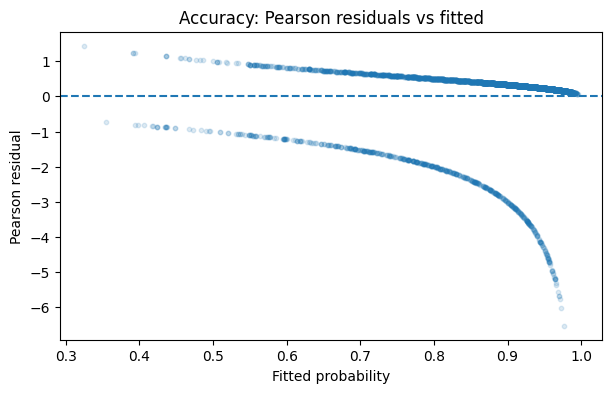

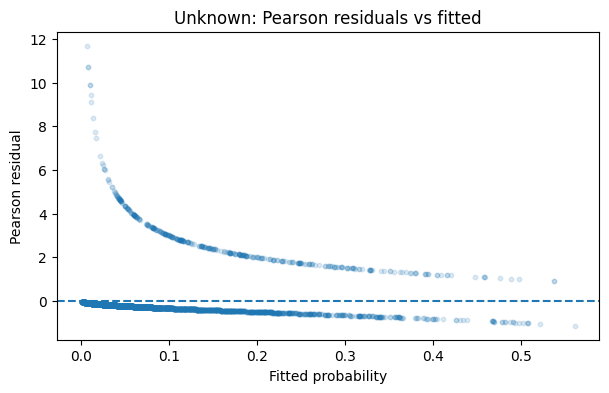

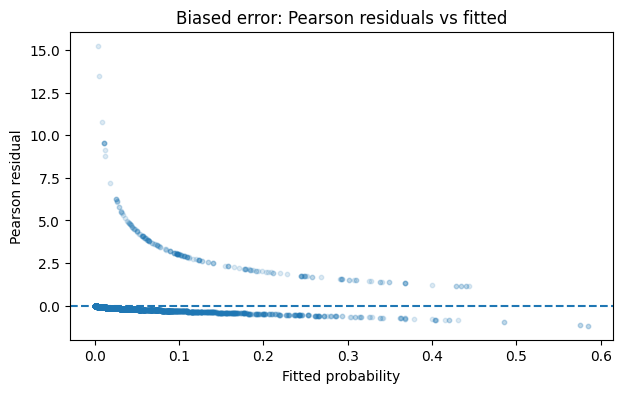

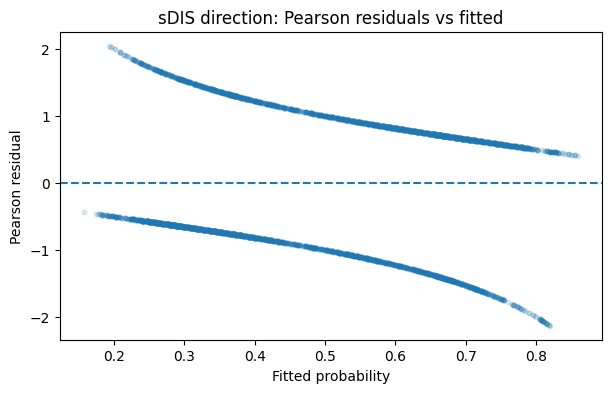

In [68]:
# =========================
# Pearson residuals vs fitted
# =========================

RANDOM_SEED = 42
MAX_POINTS = 5000

rng = np.random.default_rng(
    RANDOM_SEED
)

for outcome_name, spec in (
    gee_final_models.items()
):
    result = spec["result"]

    fitted = np.asarray(
        result.fittedvalues,
        dtype=float,
    )

    residuals = np.asarray(
        result.resid_pearson,
        dtype=float,
    )

    if len(fitted) > MAX_POINTS:
        sample_idx = rng.choice(
            len(fitted),
            size=MAX_POINTS,
            replace=False,
        )
    else:
        sample_idx = np.arange(
            len(fitted)
        )

    plt.figure(figsize=(7, 4))

    plt.scatter(
        fitted[sample_idx],
        residuals[sample_idx],
        alpha=0.15,
        s=10,
    )

    plt.axhline(
        0,
        linestyle="--",
    )

    plt.xlabel(
        "Fitted probability"
    )
    plt.ylabel(
        "Pearson residual"
    )
    plt.title(
        f"{outcome_name}: "
        "Pearson residuals vs fitted"
    )

    plt.show()


## 3. Benjamini-Hochberg FDR

FDR is computed dynamically from the prompt metrics that remain in
`prompt_metric_columns`.

Two corrections are reported:

- **within outcome:** the selected prompt-metric tests are corrected separately inside
  each GEE outcome;
- **global:** all prompt-metric tests across the four outcomes are corrected together.


In [69]:
# =========================
# Benjamini-Hochberg FDR
# =========================

fdr_rows = []

for outcome_name, spec in (
    gee_final_models.items()
):
    result = spec["result"]

    for metric in (
        standardized_prompt_metrics
    ):
        fdr_rows.append({
            "outcome": outcome_name,
            "metric": metric,
            "coefficient": (
                result.params[metric]
            ),
            "raw_p_value": (
                result.pvalues[metric]
            ),
        })

fdr_results_df = pd.DataFrame(
    fdr_rows
)

# Correction within each outcome.
fdr_results_df[
    "fdr_bh_p_within_outcome"
] = np.nan

for outcome_name in (
    fdr_results_df[
        "outcome"
    ].unique()
):
    mask = (
        fdr_results_df["outcome"]
        == outcome_name
    )

    adjusted = multipletests(
        fdr_results_df.loc[
            mask,
            "raw_p_value",
        ],
        alpha=0.05,
        method="fdr_bh",
    )

    fdr_results_df.loc[
        mask,
        "fdr_bh_p_within_outcome",
    ] = adjusted[1]

# Global correction across all prompt-metric tests.
global_adjusted = multipletests(
    fdr_results_df[
        "raw_p_value"
    ],
    alpha=0.05,
    method="fdr_bh",
)

fdr_results_df[
    "fdr_bh_p_global"
] = global_adjusted[1]

fdr_results_df[
    "significant_raw"
] = (
    fdr_results_df[
        "raw_p_value"
    ] < 0.05
)

fdr_results_df[
    "significant_fdr_within_outcome"
] = (
    fdr_results_df[
        "fdr_bh_p_within_outcome"
    ] < 0.05
)

fdr_results_df[
    "significant_fdr_global"
] = (
    fdr_results_df[
        "fdr_bh_p_global"
    ] < 0.05
)

print(
    "Within-outcome family size:",
    len(standardized_prompt_metrics),
)

print(
    "Global family size:",
    len(fdr_results_df),
)

display(
    fdr_results_df
    .sort_values(
        [
            "outcome",
            "raw_p_value",
        ]
    )
    .reset_index(drop=True)
)


Within-outcome family size: 6
Global family size: 24


,outcome,metric,coefficient,raw_p_value,fdr_bh_p_within_outcome,fdr_bh_p_global,significant_raw,significant_fdr_within_outcome,significant_fdr_global
0,Accuracy,prompt_token_count_z,0.721768,3.823317e-07,0.000002,0.000009,True,True,True
1,Accuracy,prompt_flesch_reading_ease_z,-0.465161,2.323594e-03,0.006971,0.018589,True,True,True
2,Accuracy,prompt_adjective_count_z,-0.315216,5.110362e-03,0.010221,0.030084,True,True,True
3,Accuracy,prompt_gunning_fog_index_z,-0.351018,2.428299e-02,0.036424,0.058279,True,True,False
4,Accuracy,prompt_yules_k_z,0.154231,1.166488e-01,0.139979,0.199969,False,False,False
5,Accuracy,prompt_sentence_count_z,0.061500,5.266901e-01,0.526690,0.632028,False,False,False
6,Biased error,prompt_token_count_z,-1.016379,7.408546e-03,0.044451,0.030084,True,True,True
7,Biased error,prompt_gunning_fog_index_z,0.660832,3.524024e-02,0.100144,0.076888,True,False,False
8,Biased error,prompt_adjective_count_z,0.472395,5.007223e-02,0.100144,0.100144,False,False,False
9,Biased error,prompt_flesch_reading_ease_z,0.482648,1.468120e-01,0.220218,0.207264,False,False,False


# Sensitivity analysis — Accuracy working correlation

> **Da qui in poi c'è solo una prova diagnostica separata dal modello finale.**
>
> Questa sezione ricostruisce da capo il dataset di Accuracy e rifitta lo stesso modello con le stesse metriche finali, gli stessi controlli e gli stessi cluster (`example_key`).
>
> Vengono confrontate:
>
> - `Independence` + robust sandwich covariance;
> - `Exchangeable` + robust sandwich covariance.
>
> L'obiettivo è verificare se `Exchangeable` converge con la specificazione finale a 6 metriche e, se converge, controllare quanto cambiano coefficienti, robust SE e p-value rispetto a `Independence`.
>
> Alla fine viene anche ripetuto il confronto tra **naive SE** e **robust SE**. Questo non è un test pass/fail, ma mostra quanto l'inferenza cambierebbe se ci fidassimo completamente della working correlation scelta.


In [70]:
# =========================
# Rebuild Accuracy data
# from scratch for this test
# =========================

import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Use exactly the prompt metrics currently selected
# in the main analysis (the final 6-metric specification).
sens_prompt_metrics = prompt_metric_columns.copy()

VALID_LETTERS_SENS = {"A", "B", "C"}

sens_accuracy_df = gee_analysis_df[
    gee_analysis_df["parsed_answer"]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(VALID_LETTERS_SENS)
].copy()

# Standardize again inside the Accuracy sample,
# independently from any variables created above.
for metric in sens_prompt_metrics:
    metric_mean = sens_accuracy_df[metric].mean()
    metric_std = sens_accuracy_df[metric].std()

    if (
        not np.isfinite(metric_std)
        or metric_std == 0
    ):
        raise ValueError(
            f"Cannot standardize {metric}: std={metric_std}"
        )

    sens_accuracy_df[f"{metric}_z"] = (
        sens_accuracy_df[metric] - metric_mean
    ) / metric_std

sens_standardized_metrics = [
    f"{metric}_z"
    for metric in sens_prompt_metrics
]

sens_accuracy_formula = (
    "is_correct ~ "
    + " + ".join(
        [
            *sens_standardized_metrics,
            'C(model_alias, Treatment(reference="llama31_8b"))',
            'C(prompt_type, Treatment(reference="baseline"))',
            'C(category)',
            'C(question_polarity, Treatment(reference="neg"))',
        ]
    )
)

print("Sensitivity-test sample size:", len(sens_accuracy_df))
print(
    "Clusters:",
    sens_accuracy_df["example_key"].nunique(),
)
print("Metrics:", sens_prompt_metrics)
print("\nFormula:")
print(sens_accuracy_formula)


Sensitivity-test sample size: 89001
Clusters: 594
Metrics: ['prompt_token_count', 'prompt_sentence_count', 'prompt_flesch_reading_ease', 'prompt_gunning_fog_index', 'prompt_yules_k', 'prompt_adjective_count']

Formula:
is_correct ~ prompt_token_count_z + prompt_sentence_count_z + prompt_flesch_reading_ease_z + prompt_gunning_fog_index_z + prompt_yules_k_z + prompt_adjective_count_z + C(model_alias, Treatment(reference="llama31_8b")) + C(prompt_type, Treatment(reference="baseline")) + C(category) + C(question_polarity, Treatment(reference="neg"))


In [71]:
# =========================
# Refit Accuracy with
# Independence + robust SE
# =========================

sens_independence_model = smf.gee(
    formula=sens_accuracy_formula,
    groups="example_key",
    data=sens_accuracy_df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
)

sens_independence_result = (
    sens_independence_model.fit(
        maxiter=100,
        cov_type="robust",
    )
)

print("=== Independence ===")
print("Converged:", sens_independence_result.converged)
print(
    "Finite coefficients:",
    np.isfinite(
        np.asarray(
            sens_independence_result.params,
            dtype=float,
        )
    ).all(),
)
print(
    "Finite robust SE:",
    np.isfinite(
        np.asarray(
            sens_independence_result.bse,
            dtype=float,
        )
    ).all(),
)


=== Independence ===
Converged: True
Finite coefficients: True
Finite robust SE: True


In [72]:
# =========================
# Refit Accuracy with
# Exchangeable + robust SE
# =========================

sens_exchangeable_model = None
sens_exchangeable_result = None
sens_exchangeable_exception = None
sens_exchangeable_warnings = []

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always")

    try:
        sens_exchangeable_model = smf.gee(
            formula=sens_accuracy_formula,
            groups="example_key",
            data=sens_accuracy_df,
            family=sm.families.Binomial(),
            cov_struct=sm.cov_struct.Exchangeable(),
        )

        sens_exchangeable_result = (
            sens_exchangeable_model.fit(
                maxiter=100,
                cov_type="robust",
            )
        )

    except Exception as exc:
        sens_exchangeable_exception = exc

    sens_exchangeable_warnings = [
        str(w.message)
        for w in caught_warnings
    ]


print("=== Exchangeable fit status ===")

if sens_exchangeable_exception is not None:
    print(
        "Fit raised an exception:",
        repr(sens_exchangeable_exception),
    )

elif sens_exchangeable_result is None:
    print("No result object was returned.")

else:
    print(
        "Converged:",
        sens_exchangeable_result.converged,
    )

    estimated_rho = getattr(
        sens_exchangeable_result.model.cov_struct,
        "dep_params",
        np.nan,
    )

    print(
        "Estimated exchangeable rho:",
        estimated_rho,
    )

    print(
        "Finite coefficients:",
        np.isfinite(
            np.asarray(
                sens_exchangeable_result.params,
                dtype=float,
            )
        ).all(),
    )

    print(
        "Finite robust SE:",
        np.isfinite(
            np.asarray(
                sens_exchangeable_result.bse,
                dtype=float,
            )
        ).all(),
    )

    fit_history = (
        getattr(
            sens_exchangeable_result,
            "fit_history",
            {},
        )
        or {}
    )

    if "params" in fit_history:
        print(
            "Recorded parameter states:",
            len(fit_history["params"]),
        )

print(
    "Warnings captured:",
    len(sens_exchangeable_warnings),
)

for warning_message in sens_exchangeable_warnings:
    print("-", warning_message)


=== Exchangeable fit status ===
Converged: False
Estimated exchangeable rho: nan
Finite coefficients: False
Finite robust SE: False
Recorded parameter states: 100
Warnings captured: 1094
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountered in square
- overflow encountere

In [73]:
# =========================
# Sensitivity of prompt-metric
# coefficients to working correlation
# =========================

sens_exchangeable_usable = (
    sens_exchangeable_result is not None
    and bool(sens_exchangeable_result.converged)
    and np.isfinite(
        np.asarray(
            sens_exchangeable_result.params,
            dtype=float,
        )
    ).all()
    and np.isfinite(
        np.asarray(
            sens_exchangeable_result.bse,
            dtype=float,
        )
    ).all()
)

if sens_exchangeable_usable:
    sensitivity_rows = []

    for metric_z in sens_standardized_metrics:
        beta_ind = float(
            sens_independence_result.params[metric_z]
        )
        beta_ex = float(
            sens_exchangeable_result.params[metric_z]
        )

        sensitivity_rows.append({
            "metric": metric_z,
            "beta_independence": beta_ind,
            "beta_exchangeable": beta_ex,
            "same_sign": (
                np.sign(beta_ind) == np.sign(beta_ex)
            ),
            "absolute_beta_difference": abs(
                beta_ex - beta_ind
            ),
            "relative_beta_change_pct": (
                100.0
                * abs(beta_ex - beta_ind)
                / max(abs(beta_ind), 1e-12)
            ),
            "robust_se_independence": float(
                sens_independence_result.bse[metric_z]
            ),
            "robust_se_exchangeable": float(
                sens_exchangeable_result.bse[metric_z]
            ),
            "p_independence": float(
                sens_independence_result.pvalues[metric_z]
            ),
            "p_exchangeable": float(
                sens_exchangeable_result.pvalues[metric_z]
            ),
            "or_independence": float(
                np.exp(beta_ind)
            ),
            "or_exchangeable": float(
                np.exp(beta_ex)
            ),
        })

    sens_working_correlation_comparison_df = (
        pd.DataFrame(sensitivity_rows)
    )

    display(
        sens_working_correlation_comparison_df
    )

    print(
        "\nSame coefficient sign:",
        int(
            sens_working_correlation_comparison_df[
                "same_sign"
            ].sum()
        ),
        "/",
        len(
            sens_working_correlation_comparison_df
        ),
    )

else:
    print(
        "Exchangeable did not produce a converged, "
        "finite fit. Its coefficients are therefore "
        "not interpreted or compared."
    )


Exchangeable did not produce a converged, finite fit. Its coefficients are therefore not interpreted or compared.


In [74]:
# =========================
# Robust vs naive SE
# for each usable working structure
# =========================

def sens_robust_vs_naive_table(
    result,
    metrics,
    working_structure,
):
    param_names = list(result.params.index)

    naive_cov = np.asarray(
        result.cov_naive,
        dtype=float,
    )

    naive_variances = np.diag(naive_cov)

    naive_se_values = np.where(
        naive_variances >= 0,
        np.sqrt(naive_variances),
        np.nan,
    )

    naive_se = pd.Series(
        naive_se_values,
        index=param_names,
    )

    robust_se = pd.Series(
        np.asarray(
            result.bse,
            dtype=float,
        ),
        index=param_names,
    )

    out = pd.DataFrame({
        "metric": metrics,
        "working_correlation": working_structure,
        "naive_se": [
            naive_se[m]
            for m in metrics
        ],
        "robust_se": [
            robust_se[m]
            for m in metrics
        ],
    })

    out["robust_to_naive_ratio"] = (
        out["robust_se"]
        / out["naive_se"]
    )

    return out


sens_se_tables = [
    sens_robust_vs_naive_table(
        sens_independence_result,
        sens_standardized_metrics,
        "Independence",
    )
]

if sens_exchangeable_usable:
    sens_se_tables.append(
        sens_robust_vs_naive_table(
            sens_exchangeable_result,
            sens_standardized_metrics,
            "Exchangeable",
        )
    )

sens_robust_vs_naive_df = pd.concat(
    sens_se_tables,
    ignore_index=True,
)

display(sens_robust_vs_naive_df)

print("\nRobust / naive SE ratio summary:")

display(
    sens_robust_vs_naive_df
    .groupby("working_correlation")[
        "robust_to_naive_ratio"
    ]
    .agg(["min", "median", "max"])
)


,metric,working_correlation,naive_se,robust_se,robust_to_naive_ratio
0,prompt_token_count_z,Independence,0.020260,0.142149,7.016117
1,prompt_sentence_count_z,Independence,0.015877,0.097147,6.118540
2,prompt_flesch_reading_ease_z,Independence,0.021523,0.152741,7.096818
3,prompt_gunning_fog_index_z,Independence,0.021904,0.155826,7.113992
4,prompt_yules_k_z,Independence,0.013560,0.098299,7.249263
5,prompt_adjective_count_z,Independence,0.016386,0.112577,6.870162



Robust / naive SE ratio summary:


,min,median,max
working_correlation,,,
Independence,6.11854,7.056467,7.249263


### Come leggere questa prova

- Se `Exchangeable` **non converge**, non si interpretano i suoi coefficienti: il risultato documenta semplicemente che quella working correlation rimane numericamente instabile anche con la specificazione finale.
- Se `Exchangeable` **converge**, il confronto con `Independence` diventa una sensitivity analysis: segni e coefficienti simili indicano che le associazioni principali non dipendono fortemente dalla working correlation scelta.
- Il confronto `robust SE / naive SE` mostra quanto cambia la stima dell'incertezza quando non ci si fida completamente della working correlation. Non esiste una soglia universale che costituisca un "pass".
- Questa sezione è diagnostica e non modifica i risultati del modello finale riportati sopra.
